# 摩擦能：用耗散势能近似库仑摩擦

对应代码：`friction_energy.py`，barrier 部分见 `barrier.ipynb`。

库仑摩擦是一个**不等式**：切向力 ≤ μ·λ（λ 是法向力）。这同样不方便放进能量极小化框架。
IPC 的做法是给切向滑动位移 $y$ 定义一个**耗散势能**：滑动越远能量越高，
摩擦阻碍以能量的形式进入极小化框架，Newton 法照常求解。

In [1]:
# 图中文字体:优先 Noto Sans CJK(本机 ttc 含中文字形+拉丁字符),
# 找不到就退回默认(中文显示为方框,不影响数据)
import matplotlib
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ["Noto Sans CJK JP", "Noto Sans CJK SC", "WenQuanYi Zen Hei", "Microsoft YaHei", "PingFang SC"]:
    if _f in _avail:
        matplotlib.rcParams["font.sans-serif"] = [_f, "DejaVu Sans"]
        break
matplotlib.rcParams["axes.unicode_minus"] = False

## 1. 公式

$$
D(y) = \mu\,\lambda\, f_0(\|y\|), \qquad
f_0(s) = \begin{cases}
s, & s \ge y_{eps} \quad \text{（纯滑动区）}\\[1ex]
\dfrac{s^2}{y_{eps}} - \dfrac{s^3}{3\,y_{eps}^2} + \dfrac{y_{eps}}{3}, & s < y_{eps} \quad \text{（静摩擦区）}
\end{cases}
$$

物理含义：$\|y\|$ 是接触点已经滑动的距离。$f_0$ 在滑动区就是 $\|y\|$ 本身
（能量随滑动线性涨，对应恒定摩擦力）；在静摩擦区用三次多项式把 $\|y\|$ 在 0 处的
尖角抹平。**光滑化服务于 Newton 法的收敛性，不改变物理模型。**

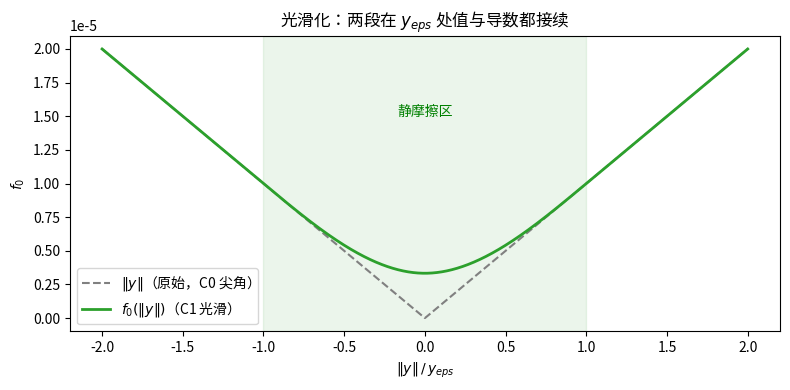

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f0(s, y_eps):
    """f0(s)，对应 friction_energy.friction_f0 kernel"""
    s = np.abs(np.asarray(s, dtype=np.float64))
    return np.where(
        s >= y_eps,
        s,
        s*s/y_eps - s**3/(3.0*y_eps*y_eps) + y_eps/3.0,
    )

Y_EPS = 1e-5   # = DT·eps_v = 0.01 × 1e-3，与 main.py 一致

s = np.linspace(-2*Y_EPS, 2*Y_EPS, 2000)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s/Y_EPS, np.abs(s), ls='--', color='gray', label=r'$\|y\|$（原始，C0 尖角）')
ax.plot(s/Y_EPS, f0(s, Y_EPS), lw=2, color='tab:green', label=r'$f_0(\|y\|)$（C1 光滑）')
ax.axvspan(-1, 1, alpha=0.08, color='green')
ax.text(0, 1.5*Y_EPS, '静摩擦区', ha='center', color='green')
ax.set_xlabel(r'$\|y\|\,/\,y_{eps}$'); ax.set_ylabel(r'$f_0$')
ax.set_title('光滑化：两段在 $y_{eps}$ 处值与导数都接续')
ax.legend()
plt.tight_layout(); plt.show()

验证接续条件：$f_0(y_{eps}) = y_{eps}$，$f_0'(y_{eps}) = 1$——两段 C1 拼接，
这正是 Newton 法需要的最低光滑度（能量 C2，梯度 C1）。

In [3]:
h = 1e-9
s_at = Y_EPS
print(f"f0(y_eps)          = {f0(s_at, Y_EPS)[()]:.12f}  (应 = y_eps = {Y_EPS})")
print(f"f0'(y_eps) 数值差分 = {(f0(s_at+h, Y_EPS)[()] - f0(s_at-h, Y_EPS)[()])/(2*h):.6f}  (应 = 1)")
print(f"f0(0)              = {f0(0.0, Y_EPS)[()]:.3e}   (应 = y_eps/3，曲线最小值不为 0 是设计使然)")

f0(y_eps)          = 0.000010000000  (应 = y_eps = 1e-05)
f0'(y_eps) 数值差分 = 1.000000  (应 = 1)
f0(0)              = 3.333e-06   (应 = y_eps/3，曲线最小值不为 0 是设计使然)


## 2. 滑动位移 y 的来源：滑动位移算子 Γ

接触点不一定在顶点上（点可能落在三角形内部或边上）。相对滑动位移用**重心坐标**
把 4 个顶点的位移混合出来。对点-三角形对（顶点 P vs 三角形 ABC，β 是接触点重心坐标）：

$$
y = T^\top \left[ \Delta x_P + (\beta_1+\beta_2-1)\,\Delta x_A - \beta_1\,\Delta x_B - \beta_2\,\Delta x_C \right]
$$

- $\Delta x$ = 当前位置 − 滞后位置 $x^n$（本步内各顶点已经动了多少）；
- $T$ = 切平面正交基（tangent0/1），把相对位移投影到接触面上——**法向分量丢掉**，
  那部分归 barrier 管，两套能量互不重复计费。

边-边对同理，混合系数换成边参数 α。

## 3. 关键取舍：λ 用滞后构型冻结（lagged data）

$\lambda = N(d)$ 本应是**当前**构型 $x$ 的函数——那样 $D(y)$ 里到处是强非线性耦合，
目标函数病态，Newton 很难收敛。

IPC 的做法：每个时间步开头，在**上一步的解 $x^n$**（滞后构型）上把这三样一次算好冻结，
整个 Newton 期间只读（`main.py` step 级 3 → `friction_energy.compute_friction_lagged_data`）：

| 冻结量 | 含义 | 作用 |
|---|---|---|
| β / α | 接触点重心/边参数 | 定义滑动算子 Γ |
| tangent0/1 | 切平面基 | 投影出切向位移 y |
| λ | barrier 力在 xⁿ 上的值 | 摩擦强度 |

**代价**：摩擦对当前步的法向变化"晚一步"响应（法向力这步涨了，摩擦力下步才跟上）。
这是 IPC 论文的标准做法，换来的是 Newton 期间目标函数固定、收敛性有保障。

下面的交互展示 λ（由压紧程度决定）如何控制摩擦能曲线的陡度：

In [4]:
import ipywidgets as w

FRICTION_MU = 0.3
y = np.linspace(-2*Y_EPS, 2*Y_EPS, 1000)

@w.interact(mu=w.FloatSlider(value=0.3, min=0.0, max=1.0, step=0.05, description='μ'),
            lam=w.FloatLogSlider(value=200, base=10, min=0, max=4, step=0.25, description='λ [N]'))
def plot_friction_energy(mu, lam):
    fig, ax = plt.subplots(figsize=(8, 4))
    D = mu * lam * f0(y, Y_EPS)
    ax.plot(y/Y_EPS, D, lw=2, color='tab:red')
    ax.set_xlabel(r'$\|y\|\,/\,y_{eps}$'); ax.set_ylabel(r'$D(y) = \mu\lambda f_0(\|y\|)$')
    ax.set_title(f'μ = {mu:.2f},  λ = {lam:.3g} N：压得越紧（λ大）曲线越陡，越难滑')
    plt.tight_layout(); plt.show()

interactive(children=(FloatSlider(value=0.3, description='μ', max=1.0, step=0.05), FloatLogSlider(value=200.0,…

## 4. 近似与细节速查

1. **y_eps = DT·eps_v**：论文里光滑化阈值是滑动**速度** eps_v；本实现直接乘上时间步
   变成**位移**阈值，和能量变量（位移）量纲对齐。
2. **wp.length 而不是 sqrt(dot)**：kernel 里 `slip_norm = wp.length(slip)`。
   slip = 0 时 `wp.length` 的自动微分梯度是 0，而手写 `sqrt(dot(slip,slip))` 的梯度是 NaN
   （这是一个常见的自动微分陷阱，见 `friction_energy.py:229` 注释）。
3. **λ = 0 时摩擦自动消失**：未激活的对（d ≥ d̂）法向力为 0，摩擦能自动为 0，
   不需要单独的激活开关。
4. **demo 里摩擦几乎不激活是正常现象**：上块自由落体压下块，横向速度小，
   滑动位移在 y_eps 以内。把 `LATERAL_OFFSET` 调大、或给上块初速度后再观察。

## 5. 与 warp kernel 的一致性检查

In [5]:
import sys; sys.path.insert(0, '..')
import warp as wp
import friction_energy

wp.init()
dev = 'cuda:0' if wp.is_cuda_available() else 'cpu'

@wp.kernel
def _check(s: wp.array[float], o: wp.array[float]):
    i = wp.tid()
    o[i] = friction_energy.friction_f0(s[i], 1e-5)

s_test = np.array([2e-6, 5e-6, 2e-5], dtype=np.float32)   # 静摩擦区×2 + 滑动区×1
s_arr = wp.array(s_test, dtype=float, device=dev)
out = wp.empty(3, dtype=float, device=dev)
wp.launch(_check, dim=3, inputs=[s_arr], outputs=[out], device=dev)

warp_vals = out.numpy()
numpy_vals = f0(s_test.astype(np.float64), 1e-5).astype(np.float32)
print('warp :', warp_vals)
print('numpy:', numpy_vals)
print('一致:', np.allclose(warp_vals, numpy_vals, rtol=1e-5))

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 5090 D v2" (23 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/oem/.cache/warp/1.14.0
Module __main__ 6465ad3 load on device 'cuda:0' took 6.79 ms  (cached)
warp : [3.7066666e-06 5.4166667e-06 1.9999999e-05]
numpy: [3.7066666e-06 5.4166667e-06 1.9999999e-05]
一致: True


## 小结

| 设计点 | 取舍 | 代价 |
|---|---|---|
| 不等式 → 耗散势能 | 摩擦进入能量极小化框架 | 摩擦力上限由 μλ 控制，不是硬约束 |
| λ/β/α/切平面滞后冻结 | Newton 目标函数固定，收敛有保障 | 摩擦响应晚一步 |
| f0 三次光滑化 | 梯度处处连续，Newton 可用 | 静摩擦区力略小于库仑值 |
| y_eps = DT·eps_v | 能量变量（位移）量纲自洽 | 换 DT 会隐式改变摩擦行为 |

回到 `barrier.ipynb` 看接触能部分。